In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_calo_hits/train-00000-of-00100.parquet", "rb") as f:
    calo_hits = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)


## Polars Quick Reference - You can skip, the analysis is below

**Key Concepts for this notebook:**

- **`lazy()`** - Converts DataFrame to LazyFrame for query optimization. Polars builds a query plan but doesn't execute until `.collect()` is called.
- **`select()`** - Choose specific columns (like SQL SELECT)
- **`explode()`** - Unnest list columns into separate rows. If a row has `[1, 2, 3]` in a column, it becomes 3 rows.
- **`filter()`** - Keep only rows matching a condition
- **`group_by()`** - Group rows by column values (like SQL GROUP BY)
- **`agg()`** - Aggregate grouped data (sum, count, mean, etc.)
- **`join()`** - Combine DataFrames on matching columns
- **`with_columns()`** - Add or modify columns
- **`collect(streaming=True)`** - Execute the lazy query with streaming (memory efficient)

**Data Structure:** Each row is an "event" containing lists of particles. We `explode()` to work with individual particles, then `group_by()` to aggregate back to event level.

In [52]:
# === PLAYGROUND: Understanding explode() and group_by() ===
# This cell demonstrates how data transforms at each step

# 1. Original data: Each row is an event with LISTS of values
print("=== ORIGINAL DATA (first 2 events) ===")
print("Each row = 1 event, columns contain LISTS of particles")
print(particles.select(['event_id', 'particle_id', 'energy']).head(2))
print(f"\nNote: particle_id and energy are lists with {len(particles['particle_id'][0])} items each\n")

# 2. After explode(): Lists become individual rows
print("=== AFTER EXPLODE (first 10 rows) ===")
print("Each row = 1 particle, lists are 'flattened'")
exploded = (
    particles.lazy()
    .select(['event_id', 'particle_id', 'energy'])
    .explode(['particle_id', 'energy'])
    .head(10)
    .collect()
)
print(exploded)
print()

# 3. After group_by + agg: Back to event-level with aggregated values
print("=== AFTER GROUP_BY + AGG (first 5 events) ===")
print("Back to 1 row per event, with aggregated results")
aggregated = (
    particles.lazy()
    .select(['event_id', 'particle_id', 'energy'])
    .explode(['particle_id', 'energy'])
    .group_by('event_id')
    .agg([
        pl.col('energy').sum().alias('total_energy'),
        pl.col('energy').mean().alias('avg_energy'),
        pl.col('particle_id').count().alias('n_particles')
    ])
    .sort('event_id')
    .head(5)
    .collect()
)
print(aggregated)

=== ORIGINAL DATA (first 2 events) ===
Each row = 1 event, columns contain LISTS of particles
shape: (2, 3)
┌──────────┬──────────────────┬─────────────────────────────────┐
│ event_id ┆ particle_id      ┆ energy                          │
│ ---      ┆ ---              ┆ ---                             │
│ u32      ┆ list[u64]        ┆ list[f32]                       │
╞══════════╪══════════════════╪═════════════════════════════════╡
│ 0        ┆ [76, 77, … 2033] ┆ [2491.611816, 489.566223, … 0.… │
│ 1        ┆ [10, 11, … 2879] ┆ [1935.443848, 28.814047, … 219… │
└──────────┴──────────────────┴─────────────────────────────────┘

Note: particle_id and energy are lists with 1846 items each

=== AFTER EXPLODE (first 10 rows) ===
Each row = 1 particle, lists are 'flattened'
shape: (10, 3)
┌──────────┬─────────────┬─────────────┐
│ event_id ┆ particle_id ┆ energy      │
│ ---      ┆ ---         ┆ ---         │
│ u32      ┆ u64         ┆ f32         │
╞══════════╪═════════════╪═════════════╡

In [ ]:
#particles_old = particles.clone()

In [ ]:
#particles = particles_old

## Data Processing Pipeline

The following cells add computed columns to the particles DataFrame:

1. **`add_orphan_mask`** - Identifies particles whose parent is not in the event (orphans). Uses a join pattern: flatten IDs → join to check existence → re-aggregate.
2. **`add_created_inside_calo_mask`** - Marks particles created inside the calorimeter based on vertex position (vx, vy, vz).
3. **`add_eta_and_phi`** - Calculates pseudorapidity (η), azimuthal angle (φ), and transverse momentum (pt) from momentum components.
4. **`add_particle_have_track_mask`** - Adds a boolean mask indicating if a particle was reconstructed as a track (matched via `majority_particle_id` from tracks data).
5. **`add_target_mask`** - Identifies "target" particles: created before calorimeter but have children created inside or particles thst have a track.
                            
                            (Note regarding 'target' definition - We did lot of other varations, they all yielded about the same result)

In [3]:
def add_orphan_mask(df: pl.DataFrame) -> pl.DataFrame:
    print("Computing parent existence mask...")
    # if is_parent_missing exist in df, drop it
    if "is_parent_missing" in df.columns:
        df = df.drop("is_parent_missing")
    
    # 1. Build Lookup Table
    valid_ids_lookup = (
        df.lazy()
        .select(["event_id", "particle_id"])
        .explode("particle_id")
        .rename({"particle_id": "valid_pid"})
        # Ensure ID types match (Int64 vs Int64)
        .with_columns(pl.col("valid_pid").cast(pl.Int64))
        .unique()
        # We need this because 'valid_pid' gets dropped during the join.
        .with_columns(pl.lit(True).alias("found_in_event")) 
    )

    # 2. Flatten Parent IDs
    # (Assuming you already ran cast_parent_id_to_int64, so parent_id is Int64)
    parents_flat = (
        df.lazy()
        .select(["event_id", "parent_id"])
        .explode("parent_id")
        .with_row_index("original_order")
    )

    # 3. Join
    matched = parents_flat.join(
        valid_ids_lookup,
        left_on=["event_id", "parent_id"],
        right_on=["event_id", "valid_pid"],
        how="left"
    )

    # 4. Check the Tracer
    result_mask = (
        matched
        .sort("original_order")
        .with_columns(
            # If 'found_in_event' is Null, the join failed -> Parent Missing
            pl.col("found_in_event").is_null().alias("is_parent_missing")
        )
        .group_by("event_id", maintain_order=True)
        .agg(pl.col("is_parent_missing"))
    )

    # 5. Merge back
    return (
        df.lazy()
        .join(result_mask, on="event_id", how="left")
        .collect(streaming=True)
    )

In [4]:
def add_created_inside_calo_mask(particles: pl.DataFrame) -> pl.DataFrame:
    """
    r_xy_sq_threshold = 1250 ** 2
    z_threshold = 3200
    r_min_barrel = 315**2
    """
    # new values

    # 2. Create the Mask Calculation Query
    # We use a separate LazyFrame to calculate masks. This ensures we don't 
    # explode the massive columns (particle_id, parents, etc.) in RAM.
    mask_query = (
        particles.lazy()
        .select(["event_id", "vx", "vy", "vz"]) # Project only what is needed
        .explode(["vx", "vy", "vz"])            # Flatten
        .select([
            pl.col("event_id"),
            (
                # Logic: (vx^2 + vy^2) > 1250^2  OR  
                ~(((pl.col("vx").pow(2) + pl.col("vy").pow(2))< 1080)
                & ((pl.col("vz").abs() < 3030)))
                
                #((pl.col("vz").abs() > z_threshold) & ((pl.col("vx").pow(2) + pl.col("vy").pow(2)) > r_min_barrel))
            ).alias("created_inside_calo")
        ])
        # IMPORTANT: maintain_order=True guarantees the mask list 
        # aligns perfectly index-by-index with particle_id list
        .group_by("event_id", maintain_order=True)
        .agg(pl.col("created_inside_calo"))
    )

    # 3. Join back to original data and Collect
    # We use join(how="left") to attach the new column.
    result = (
        particles.lazy()
        .join(mask_query, on="event_id", how="left")
        # Handle cases where an event might have empty lists (join results in null)
        .with_columns(pl.col("created_inside_calo").fill_null([]))
        .collect(streaming=True)
    )

    return result

In [6]:
def add_eta_and_phi(particles: pl.DataFrame) -> pl.DataFrame:
    """
    Adds 'eta' and 'phi' columns calculated from momentum components (px, py, pz).
    
    Formulas:
    pt = sqrt(px^2 + py^2)
    phi = arctan2(py, px)
    theta = arctan2(pt, pz)
    eta = -ln(tan(theta / 2))
    """
    # Calculate eta and phi on flattened data to be memory efficient
    calculations = (
        particles.lazy()
        .select(["event_id", "px", "py", "pz"])
        .explode(["px", "py", "pz"])
        .with_columns(
            (pl.col("px").pow(2) + pl.col("py").pow(2)).sqrt().alias("pt"),
            pl.arctan2(pl.col("py"), pl.col("px")).alias("phi")
        )
        .with_columns(
            pl.arctan2(pl.col("pt"), pl.col("pz")).alias("theta")
        )
        .with_columns(
            (-((pl.col("theta") / 2).tan().log())).alias("eta")
        )
        .group_by("event_id", maintain_order=True)
        .agg([
            pl.col("eta"),
            pl.col("phi"),
            pl.col("pt")
        ])
    )

    return (
        particles.lazy()
        .join(calculations, on="event_id", how="left")
        .with_columns([
            pl.col("eta").fill_null([]),
            pl.col("phi").fill_null([]),
            pl.col("pt").fill_null([])
        ])
        .collect(streaming=True)
    )

In [7]:
def add_target_mask(particles: pl.DataFrame) -> pl.DataFrame:
    calo_particles = (
                particles.lazy()
                .select('event_id', 'particle_id', 'is_parent_missing', 'created_inside_calo')
                .explode(['particle_id',  'is_parent_missing', 'created_inside_calo'])
                .join(
                    particles.lazy()
                    .select('event_id',  'parent_id', 'is_parent_missing', 'created_inside_calo')
                    .explode([ 'parent_id', 'is_parent_missing', 'created_inside_calo']),
                    left_on=['event_id', 'particle_id'],
                    right_on=['event_id', 'parent_id'],
                    how='inner',
                    suffix="_child"
                )
                .filter(((~pl.col('created_inside_calo')) &
                        (pl.col('created_inside_calo_child'))))
            .select(['event_id', 'particle_id'])
    )

    has_track = (
                particles.lazy()
                .select(['event_id', 'particle_id', 'has_track'])
                .explode(['particle_id', 'has_track'])
                .filter(pl.col('has_track'))
                .select(['event_id', 'particle_id'])
    )
    target_particles = pl.concat([calo_particles, has_track]).unique().with_columns(pl.lit(True).alias('is_target_particle'))
    # 2. Join back to original data efficiently
    return (
        particles.lazy()
        .select(["event_id", "particle_id"])
        .explode("particle_id")
        .join(
            target_particles,
            on=["event_id", "particle_id"],
            how="left"
        )
        .with_columns(pl.col("is_target_particle").fill_null(False))
        .group_by("event_id", maintain_order=True)
        .agg(pl.col("is_target_particle"))
        .join(
            particles.lazy(),
            on="event_id",
            how="inner"
        )
        .collect(streaming=True)
    )


In [94]:
def add_particle_have_track_mask(particles: pl.DataFrame, tracks: pl.DataFrame) -> pl.DataFrame:
    """
    Adds a boolean mask 'has_track' with explicit type casting and order preservation.
    """
    # 1. Prepare Tracks: Cast ID to Int64 and deduplicate
    tracked_particles = (
        tracks.lazy()
        .select(["event_id", "majority_particle_id"])
        .explode("majority_particle_id")
        .with_columns(pl.col("majority_particle_id").cast(pl.Int64))
        .unique()
        .with_columns(pl.lit(True).alias("has_track"))
    )

    # 2. Prepare Particles: Explode -> Index -> Join -> Sort -> Group
    return (
        particles.lazy()
        .select(["event_id", "particle_id"])
        .explode("particle_id")
        .with_columns(pl.col("particle_id").cast(pl.Int64))
        # FIX STEP 1: Capture the original order after exploding but before joining
        .with_row_index("original_order") 
        .join(
            tracked_particles,
            left_on=["event_id", "particle_id"],
            right_on=["event_id", "majority_particle_id"],
            how="left"
        )
        .with_columns(pl.col("has_track").fill_null(False))
        # FIX STEP 2: Restore the original order before aggregating
        .sort("original_order")
        .group_by("event_id", maintain_order=True)
        .agg(pl.col("has_track"))
        .join(
            particles.lazy(),
            on="event_id",
            how="inner"
        )
        .collect(streaming=True)
    )

In [95]:
# running this cell twice might cause issues, reload the particles dataframe before running again
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_eta_and_phi(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_target_mask(particles)


Computing parent existence mask...


/tmp/ipykernel_2376181/1808253783.py:53: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)
/tmp/ipykernel_2376181/1750874975.py:39: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)
/tmp/ipykernel_2376181/729158228.py:42: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)
/tmp/ipykernel_2376181/840527844.py:46: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


In [96]:
(particles.lazy()
 .select('event_id', 'particle_id', 'is_parent_missing', 'has_track')
 .explode([ 'particle_id', 'is_parent_missing', 'has_track'])
 .filter(pl.col('has_track'))).collect()


event_id,particle_id,is_parent_missing,has_track
u32,u64,bool,bool
221,108,true,true
221,121,true,true
221,123,true,true
221,245,true,true
221,246,true,true
…,…,…,…
38,1308,false,true
38,1309,false,true
38,2944,false,true


In [97]:
(
tracks.lazy()
 .select(['event_id', 'majority_particle_id']  )
 .explode('majority_particle_id')
 .filter((pl.col('majority_particle_id')==108) & (pl.col('event_id') ==221))
).collect()

event_id,majority_particle_id
u32,u64
221,108


=== Charged Pion Tracking Efficiency ===
Selection:
  - |pdg_id| == 211 (charged pions)
  - pt > 10 GeV, |eta| < 3
  - Created inside beampipe (r < 5 mm)
  - Has children created in calorimeter

Results:
  Total pions passing selection: 3136
  Pions with matched track:      45
  Tracking efficiency:           1.4%


/tmp/ipykernel_2376181/1063101805.py:54: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


In [29]:
result

{'n_total': 3136,
 'n_tracked': 45,
 'efficiency': 0.014349489795918368,
 'data': shape: (3_136, 9)
 ┌──────────┬─────────────┬────────┬───────────┬───┬───────────┬───────────┬───────────┬────────────┐
 │ event_id ┆ particle_id ┆ pdg_id ┆ pt        ┆ … ┆ vx        ┆ vy        ┆ has_track ┆ has_calo_c │
 │ ---      ┆ ---         ┆ ---    ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ hild       │
 │ u32      ┆ u64         ┆ i64    ┆ f32       ┆   ┆ f32       ┆ f32       ┆ bool      ┆ ---        │
 │          ┆             ┆        ┆           ┆   ┆           ┆           ┆           ┆ bool       │
 ╞══════════╪═════════════╪════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪════════════╡
 │ 639      ┆ 234         ┆ -211   ┆ 14.079949 ┆ … ┆ 0.000264  ┆ -0.00724  ┆ false     ┆ true       │
 │ 697      ┆ 479         ┆ -211   ┆ 19.618921 ┆ … ┆ -0.005697 ┆ -0.009618 ┆ false     ┆ true       │
 │ 512      ┆ 818         ┆ 211    ┆ 10.793719 ┆ … ┆ -0.003593 ┆ 0.000244  ┆ false  

In [98]:
def histogram_ht_ratio(particles: pl.DataFrame, eta_cut:float, pt_cut:float)-> pl.DataFrame:
    # sum pt of target particles within eta cut, pt cut
    ht_target = (
    particles.lazy()
    .select(['event_id', 'particle_id','pt', 'eta', 'is_target_particle', 'pdg_id'])
    .explode(['particle_id','pt', 'eta', 'is_target_particle', 'pdg_id'])
    .filter((pl.col('is_target_particle') &
            (pl.col('eta').abs() < eta_cut) &
            (pl.col('pt') > pt_cut) ) &
            # filter out neutrinos
             ((pl.col('pdg_id').abs() != 12) & (pl.col('pdg_id').abs() != 14) & (pl.col('pdg_id').abs() != 16) )
            )
    .group_by('event_id')
    .agg(pl.col('pt').sum().alias('ht_target'))
    )

    ht_truth =(
    particles.lazy()
    .select(['event_id', 'particle_id','pt', 'eta', 'is_parent_missing', 'pdg_id'])
    .explode(['particle_id','pt', 'eta', 'is_parent_missing', 'pdg_id'])
    .filter((pl.col('is_parent_missing') &
            (pl.col('eta').abs() < eta_cut) &
            (pl.col('pt') > pt_cut) )&
               ((pl.col('pdg_id').abs() != 12) & (pl.col('pdg_id').abs() != 14) & (pl.col('pdg_id').abs() != 16) ))
    .group_by('event_id')
    .agg(pl.col('pt').sum().alias('ht_truth'))
    )
    ht_combined = ht_target.join(ht_truth, on='event_id', how='inner').collect(streaming=True)

    import matplotlib.pyplot as plt
    import numpy as np

    # Convert to numpy for plotting
    x = ht_combined['ht_truth'].to_numpy()
    y = ht_combined['ht_target'].to_numpy()

    # Calculate ratio
    ratio = np.divide(y, x, out=np.zeros_like(y), where=x!=0)

    plt.figure(figsize=(10, 6))
    plt.hist(ratio, bins=50, range=(0, 2), color='blue', edgecolor='black', alpha=0.7)
    plt.title(f"Ratio of Target HT / Truth HT (eta_cut={eta_cut}, pt_cut={pt_cut})")
    plt.xlabel("HT Target / HT Truth")
    plt.ylabel("Number of Events") 
    return ht_combined



/tmp/ipykernel_2376181/2313679553.py:28: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ht_combined = ht_target.join(ht_truth, on='event_id', how='inner').collect(streaming=True)


event_id,ht_target,ht_truth
u32,f32,f32
362,142.345688,996.571045
228,44.112648,1202.67395
711,135.27002,537.254639
294,118.116455,445.122681
318,55.797825,320.083771
…,…,…
291,41.700775,363.06723
985,58.532379,539.690125
673,112.708191,456.292603


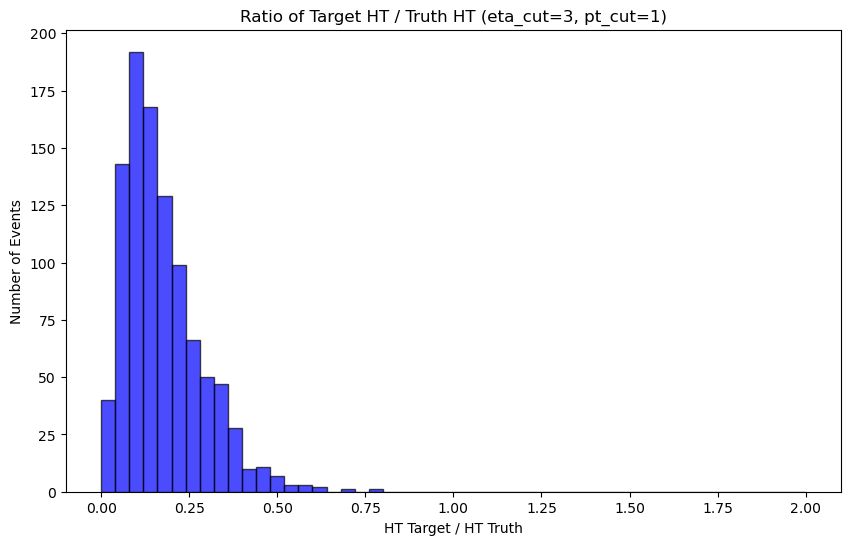

In [99]:
histogram_ht_ratio(particles, eta_cut=3, pt_cut=1)

In [ ]:

def plot_vx_vy_scatter(particles: pl.DataFrame, n_events: int = 5, eta_cut: float = 1.0, pt_cut: float = 1.0):
    """
    Scatter plot of particle creation vertices (vx, vy) for particles with |eta| < eta_cut.
    
    Args:
        particles: DataFrame with particle data
        n_events: Number of events to plot
        eta_cut: Maximum |eta| value (default 1.0)
    """
    # Filter particles with |eta| < eta_cut for first n_events
    data = (
        particles.lazy()
        .filter(pl.col('event_id') < n_events)
        .select(['event_id', 'vx', 'vy', 'eta', 'pt', 'is_parent_missing'])
        .explode(['vx', 'vy', 'eta', 'pt', 'is_parent_missing'])
        .filter((pl.col('eta').abs() < eta_cut) &
                (pl.col('pt').abs() > pt_cut)
                #&(~pl.col('is_parent_missing'))
        )
        .collect()
    )
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot each event with a different color
    colors = plt.cm.tab10(np.linspace(0, 1, n_events))
    
    for i, event_id in enumerate(range(n_events)):
        event_data = data.filter(pl.col('event_id') == event_id)
        if len(event_data) == 0:
            continue
        vx = event_data['vx'].to_numpy()
        vy = event_data['vy'].to_numpy()
        s = event_data['pt'].to_numpy()
        ax.scatter(vx, vy, s=s, alpha=0.5) #, label=f'Event {event_id}', color=colors[i])
    
    # Draw circle of radius 1250
    circle = plt.Circle((0, 0), 1250, fill=False, color='red', linestyle='--', linewidth=2, label='r=1250 mm')
    circle2 = plt.Circle((0, 0), 1150, fill=False, color='black', linestyle='-', linewidth=1, label='r=1150 mm')

    ax.add_patch(circle)
    ax.add_patch(circle2)
    ax.set_xlabel('vx [mm]')
    ax.set_ylabel('vy [mm]')
    ax.set_title(f'Particle Creation Vertices (|η| < {eta_cut}, first {n_events} events)')
    ax.set_aspect('equal')
    ax.legend(loc='upper right', markerscale=3)
    ax.grid(alpha=0.3)
    #ax.set_ylim(-5, 5)
    #ax.set_xlim(-5, 5)

    plt.tight_layout()
    plt.show()
    
    return data

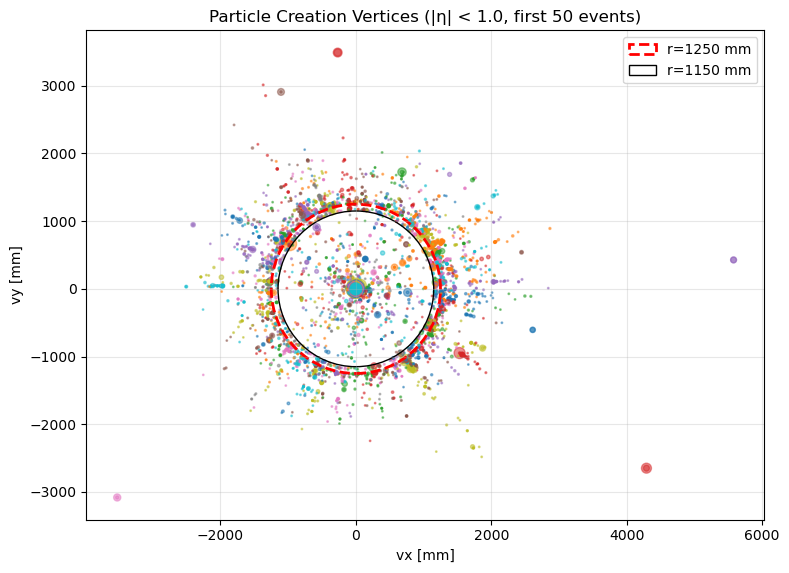

event_id,vx,vy,eta,pt,is_parent_missing
u32,f32,f32,f32,f32,bool
43,-0.034233,0.007477,-0.252601,1.667494,true
43,-0.034233,0.007477,-0.873007,2.758522,true
43,-0.034233,0.007477,-0.782422,2.03863,true
43,-0.034233,0.007477,-0.82872,1.54026,true
43,-0.034233,0.007477,-0.91961,4.086191,true
…,…,…,…,…,…
47,-621.661926,1532.190918,-0.120629,1.721504,false
47,-621.661926,1532.190918,-0.352098,1.008434,false
47,-504.069397,1366.955811,-0.514791,1.041826,false


In [96]:
plot_vx_vy_scatter(particles, n_events=50, eta_cut=1.0, pt_cut=1.0)

/tmp/ipykernel_2376181/2313679553.py:28: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ht_combined = ht_target.join(ht_truth, on='event_id', how='inner').collect(streaming=True)


event_id,ht_target,ht_truth
u32,f32,f32
441,102.298172,385.972809
468,89.681412,466.259979
35,101.478043,449.581329
373,84.783203,473.729401
912,58.83453,386.330383
…,…,…
880,187.632172,657.865356
816,143.05571,664.358521
271,82.159187,633.075867


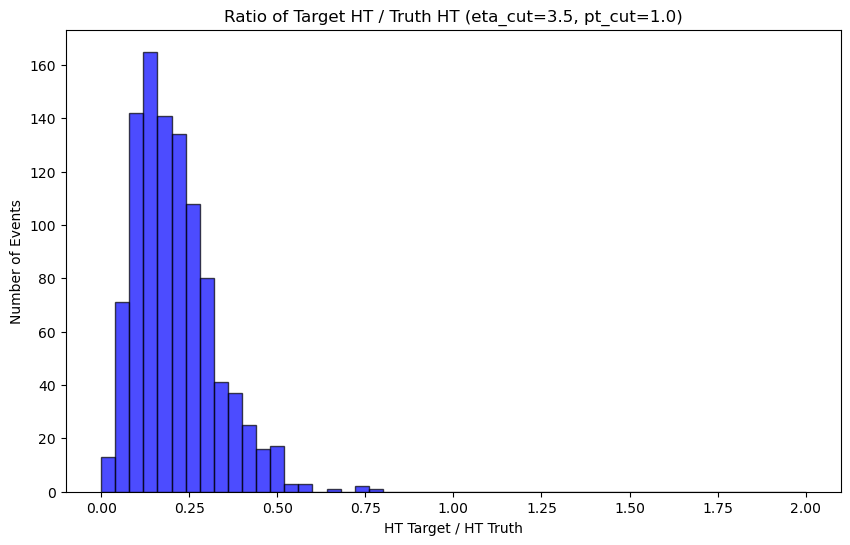

In [11]:
histogram_ht_ratio(particles, eta_cut=3.5, pt_cut=1.0)

In [20]:
truth_subset = (
    particles.lazy()
    .select([
        'pt', 'eta', 'pdg_id', 'charge',   # Physics properties
        'is_parent_missing',  'primary'    ,              # Truth definition
        'has_track',                       # Success criteria for Charged
        'is_target_particle'               # Success criteria for Neutral
        ,'event_id'
    ])
    .explode([
        'pt', 'eta', 'pdg_id', 'charge', 
        'is_parent_missing', 'has_track', 'is_target_particle', 'primary'
    ])
    # 2. Filter for TRUTH (The Denominator)
    .filter(
        ((pl.col('is_parent_missing'))) &                 # Must be Orphan or Primary
        (pl.col('eta').abs() < 3) &               # Fiducial Eta
        (pl.col('pt') > 10) &                       # Fiducial Pt
        (pl.col('charge').abs()> 0) &
        (~pl.col('pdg_id').abs().is_in([12, 14, 16]))   # Veto Neutrinos
    )
    # count total number of truth particles per event
    
)

truth_count = truth_subset.group_by('event_id').agg(
    pl.count().alias('n_truth_particles'),
    pl.col('has_track').sum().alias('n_tracked_particles'),
    pl.col('is_parent_missing').sum().alias('n_missing_parent_particles')
    ).collect(streaming=True)

/tmp/ipykernel_2376181/1355887781.py:27: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('n_truth_particles'),
/tmp/ipykernel_2376181/1355887781.py:30: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


In [21]:
truth_count.filter(pl.col('n_tracked_particles')>0)

event_id,n_truth_particles,n_tracked_particles,n_missing_parent_particles
u32,u32,u32,u32
731,3,1,3
214,2,1,2
512,9,1,9
556,3,1,3
379,7,1,7
…,…,…,…
206,14,1,14
423,10,1,10
630,6,1,6


=== Tracking Efficiency Analysis (|eta| < 3.0, pt > 10.0 GeV) ===

Total truth particles: 3148
Tracked particles:     2996
Tracking efficiency:   95.2%



/tmp/ipykernel_2376181/3937438729.py:32: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('n_truth_particles'),
/tmp/ipykernel_2376181/3937438729.py:34: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


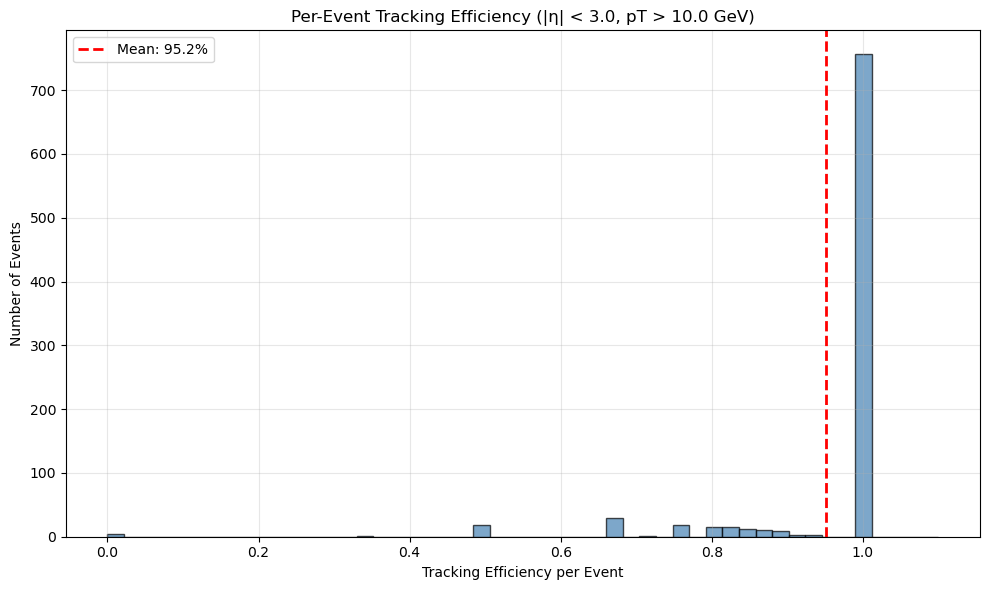

event_id,n_truth_particles,n_tracked_particles
u32,u32,u32
529,2,2
782,3,2
392,1,1
40,12,12
686,5,5
…,…,…
365,8,7
493,1,1
618,1,0


In [100]:
def tracking_efficiency(particles: pl.DataFrame, eta_cut: float, pt_cut: float):
    print(f"=== Tracking Efficiency Analysis (|eta| < {eta_cut}, pt > {pt_cut} GeV) ===\n")

    # 1. Prepare the Data
    truth_subset = (
        particles.lazy()
        .select([
            'pt', 'eta', 'pdg_id', 'charge',
            'is_parent_missing', 'primary',
            'has_track',
            'is_target_particle',
            'event_id', 'vx', 'vy'
        ])
        .explode([
            'pt', 'eta', 'pdg_id', 'charge', 
            'is_parent_missing', 'has_track', 'is_target_particle', 'primary', 'vx', 'vy'
        ])
        .filter(
            #vx^2+vy^2<100
            (pl.col('vx')**2 + pl.col('vy')**2 < 25) &
            #(pl.col('is_parent_missing')) &
            (pl.col('eta').abs() < eta_cut) &
            (pl.col('pt') > pt_cut) &
            (pl.col('pdg_id').abs() == 211) &   # Only charged pions
           # (pl.col('charge').abs() > 0) &
            (~pl.col('pdg_id').abs().is_in([12, 14, 16]))
        )
    )

    # 2. Per-event counts
    truth_count = truth_subset.group_by('event_id').agg(
        pl.count().alias('n_truth_particles'),
        pl.col('has_track').sum().alias('n_tracked_particles')
    ).collect(streaming=True)

    # 3. Calculate totals
    total_truth = truth_count['n_truth_particles'].sum()
    total_tracked = truth_count['n_tracked_particles'].sum()
    
    print(f"Total truth particles: {total_truth}")
    print(f"Tracked particles:     {total_tracked}")
    print(f"Tracking efficiency:   {total_tracked / total_truth:.1%}\n")

    # 4. Per-event efficiency distribution
    import matplotlib.pyplot as plt
    import numpy as np

    efficiency = (truth_count['n_tracked_particles'] / truth_count['n_truth_particles']).to_numpy()
    
    plt.figure(figsize=(10, 6))
    plt.hist(efficiency, bins=50, range=(0, 1.1), color='steelblue', edgecolor='black', alpha=0.7)
    plt.axvline(total_tracked / total_truth, color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {total_tracked / total_truth:.1%}')
    plt.xlabel('Tracking Efficiency per Event')
    plt.ylabel('Number of Events')
    plt.title(f'Per-Event Tracking Efficiency (|η| < {eta_cut}, pT > {pt_cut} GeV)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return truth_count

# Run the analysis
tracking_efficiency(particles, eta_cut=3.0, pt_cut=10.0)

In [34]:
event_particles = (
    particles.lazy()
    .filter(pl.col('event_id') == 639)
    .select(['particle_id', 'pdg_id', 'pt', 'eta', 'vx', 'vy', 'has_track'])
    .explode(['particle_id', 'pdg_id', 'pt', 'eta', 'vx', 'vy', 'has_track'])
    .collect()
)

In [37]:
import numpy as np
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)


In [42]:
event_particles = (
    particles.lazy()
    .select(['event_id','particle_id', 'pdg_id', 'px', 'py', 'pz'])
    .filter(pl.col('event_id') == event_id)
    .explode(['particle_id', 'pdg_id', 'px', 'py', 'pz'])
    .collect(streaming=True)
)

/tmp/ipykernel_2376181/4211350545.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


In [101]:
matched_pions_count = 0
total_selected_pions = 0
for event_id in range(1000):
    event_particles = (
        particles.lazy()
        .select(['event_id', 'particle_id', 'pdg_id', 'px', 'py', 'pz', 'vx', 'vy', 'charge'])
        .filter(pl.col('event_id') == event_id)
        .explode(['particle_id', 'pdg_id', 'px', 'py', 'pz', 'vx', 'vy', 'charge'])
        .collect(streaming=True)
    )

    # Convert to numpy arrays
    particle_id = event_particles['particle_id'].to_numpy()
    pdg_id = event_particles['pdg_id'].to_numpy()
    px = event_particles['px'].to_numpy()
    py = event_particles['py'].to_numpy()
    pz = event_particles['pz'].to_numpy()
    vx = event_particles['vx'].to_numpy()
    vy = event_particles['vy'].to_numpy()
    charge = event_particles['charge'].to_numpy()

    # Calculate pt and eta with numpy
    pt = np.sqrt(px**2 + py**2)
    theta = np.arctan2(pt, pz)  # theta = arctan2(pt, pz)
    eta = -np.log(np.tan(theta / 2))  # eta = -ln(tan(theta/2))

    # Step 2: Filter tracks for event
    event_tracks = (
        tracks.lazy()
        .filter(pl.col('event_id') == event_id)
        .select(['track_id', 'majority_particle_id'])
        .explode(['track_id', 'majority_particle_id'])
        .collect()
    )

    track_particle_ids = event_tracks['majority_particle_id'].to_numpy()
    n_tracks = len(np.unique(track_particle_ids))

    # Step 3: Apply pion selection
    r_xy = np.sqrt(vx**2 + vy**2)

    pion_mask = (
        (np.abs(pdg_id) == 211) &    # Charged pions
        (pt > 1) &                   # pt > 10 GeV
        (np.abs(eta) < 3) &           # |eta| < 3
        (r_xy < 5)                    # Inside beampipe (r < 5 mm)
    )

    # Step 4: Count results
    n_selected_pions = np.sum(pion_mask)

    # Check which pions are in the track list
    selected_pion_ids = particle_id[pion_mask]
    pions_matched_to_tracks = np.isin(selected_pion_ids, track_particle_ids)
    n_pions_in_track_list = np.sum(pions_matched_to_tracks)
    matched_pions_count +=n_pions_in_track_list
    total_selected_pions += n_selected_pions

            
print(f"\n=== Overall Summary ===")
print(f"Total selected pions across events: {total_selected_pions}")
print(f"Total matched pions across events: {matched_pions_count}")  
# efficiency = matched_pions_count / total_selected_pions if total_selected_pions > 0 else 0
print(f"Overall tracking efficiency for selected pions: {matched_pions_count / total_selected_pions :.1%}")

/tmp/ipykernel_2376181/4064806351.py:9: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)
/tmp/ipykernel_2376181/4064806351.py:25: RuntimeWarning: invalid value encountered in log
  eta = -np.log(np.tan(theta / 2))  # eta = -ln(tan(theta/2))
/tmp/ipykernel_2376181/4064806351.py:25: RuntimeWarning: divide by zero encountered in log
  eta = -np.log(np.tan(theta / 2))  # eta = -ln(tan(theta/2))



=== Overall Summary ===
Total selected pions across events: 36061
Total matched pions across events: 33554
Overall tracking efficiency for selected pions: 93.0%


In [79]:
matched_count = 0
total_selected = 0

for event_id in range(1000):
    event_particles = (
        particles.lazy()
        .select(['event_id', 'particle_id', 'pdg_id', 'px', 'py', 'pz', 'vx', 'vy', 'charge'])
        .filter(pl.col('event_id') == event_id)
        .explode(['particle_id', 'pdg_id', 'px', 'py', 'pz', 'vx', 'vy', 'charge'])
        .collect(streaming=True)
    )

    # Convert to numpy arrays
    particle_id = event_particles['particle_id'].to_numpy()
    pdg_id = event_particles['pdg_id'].to_numpy()
    px = event_particles['px'].to_numpy()
    py = event_particles['py'].to_numpy()
    pz = event_particles['pz'].to_numpy()
    vx = event_particles['vx'].to_numpy()
    vy = event_particles['vy'].to_numpy()
    charge = event_particles['charge'].to_numpy()

    # Calculate pt and eta with numpy
    pt = np.sqrt(px**2 + py**2)
    theta = np.arctan2(pt, pz)  # theta = arctan2(pt, pz)
    eta = -np.log(np.tan(theta / 2))  # eta = -ln(tan(theta/2))

    # Step 2: Filter tracks for event
    event_tracks = (
        tracks.lazy()
        .filter(pl.col('event_id') == event_id)
        .select(['track_id', 'majority_particle_id'])
        .explode(['track_id', 'majority_particle_id'])
        .collect()
    )

    track_particle_ids = event_tracks['majority_particle_id'].to_numpy()
    n_tracks = len(np.unique(track_particle_ids))

    # Step 3: Apply pion selection
    r_xy = np.sqrt(vx**2 + vy**2)

    charged_mask = (
        (charge!=0) &    # Charged pions
        (pt > 10) &                   # pt > 10 GeV
        (np.abs(eta) < 3) &           # |eta| < 3
        (r_xy < 5)                    # Inside beampipe (r < 5 mm)
    )

    # Step 4: Count results
    n_selected_charge = np.sum(charged_mask)

    # Check which pions are in the track list
    selected_charge_ids = particle_id[charged_mask]
    charge_matched_to_tracks = np.isin(selected_charge_ids, track_particle_ids)
    n_charge_in_track_list = np.sum(charge_matched_to_tracks)
    total_selected += n_selected_charge
    matched_count += n_charge_in_track_list
    if n_charge_in_track_list/n_selected_charge < 0.8 and n_selected_charge>100:

        print(f"=== Event {event_id} Analysis ===")
        print(f"\nParticles:")
        print(f"  Total particles in event: {len(particle_id)}")
        print(f"  Charged particles passing selection:  {n_selected_charge}")
        print(f"  Charged particles matched in track list: {n_charge_in_track_list}")

        print(f"\nTracks:")
        print(f"  Total tracks in event: {n_tracks}")

        print(f"\nEfficiency:")
        if n_selected_charge > 0:
            print(f"  Tracking efficiency: {n_charge_in_track_list / n_selected_charge:.1%}")
        else:
            print(f"  No charged particles passing selection")

        # Debug: Show some charged particle details
        print(f"\n--- Selected Charged Particles Detail ---")
        for i, idx in enumerate(np.where(charged_mask)[0][:10]):  # First 10
            matched = particle_id[idx] in track_particle_ids
            print(f"  pid={particle_id[idx]}, pt={pt[idx]:.1f}, eta={eta[idx]:.2f}, "
                f"r={r_xy[idx]:.2f}mm, has_track={matched}")

print(f"\n=== Overall Summary ===")
print(f"Total selected charged particles across events: {total_selected}")
print(f"Total matched charged particles across events: {matched_count}")
print(f"Overall tracking efficiency for selected charged particles: {matched_count / total_selected :.1%}")

/tmp/ipykernel_2376181/1559299129.py:10: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)
/tmp/ipykernel_2376181/1559299129.py:26: RuntimeWarning: invalid value encountered in log
  eta = -np.log(np.tan(theta / 2))  # eta = -ln(tan(theta/2))
/tmp/ipykernel_2376181/1559299129.py:26: RuntimeWarning: divide by zero encountered in log
  eta = -np.log(np.tan(theta / 2))  # eta = -ln(tan(theta/2))



=== Overall Summary ===
Total selected charged particles across events: 9514
Total matched charged particles across events: 4953
Overall tracking efficiency for selected charged particles: 52.1%
